# Yield (KS4)

**author**: laquitainesteeve@gmail.com

**purpose**: Plot number of isolated single-units by site (ratio) by experiment for KS4

**tested on**:

* Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz) with RTX 5090 GPU with 40GB VRAM (GPU not needed)

## Setup

1. Setup "_envs/spikebias.yml_" virtual environment
2. Setup jupyter kernel _$python -m ipykernel install --user --name spikebias --display-name "spikebias"_
3. Download with 
    - notebooks/0_download_sortings.ipynb
    - notebooks/0_download_ground_truths.ipynb
    - notebooks/0_download_recordings.ipynb

In [11]:
# SETUP PACKAGES 
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib
import spikeinterface as si
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

# SET PROJECT PATH
PROJ_PATH = "/home/steeve/steeve/epfl/code/spikebias"
os.chdir(PROJ_PATH)

# custom package
# from src.nodes.utils import get_config, savefig
from src.nodes.analysis.failures import the_yield
# from src.nodes import utils
# from src.nodes.postpro import metadata as meta

# DATASETS

# NEUROPIXELS

# Marques-Smith (M)
KS4_m = "dataset/01_intermediate/sorting/marques/SortingKS4_10m"
REC_m = "dataset/00_raw/recording_marques_smith/"

# npx synth (S)
KS4_nb = "dataset/01_intermediate/sorting/buccino/SortingKS4_10m"
REC_nb = "dataset/00_raw/recording_buccino/"

# npx spont. biophy (NS)
KS4_ns = "dataset/01_intermediate/sorting/npx_spont/SortingKS4_10m"
REC_ns = "dataset/00_raw/recording_npx_spont/"
GT_ns = "dataset/00_raw/ground_truth_npx_spont"

# npx evoked. biophy (NE)
KS4_ne = "dataset/01_intermediate/sorting/npx_evoked/SortingKS4_10m"
REC_ne = "dataset/00_raw/recording_npx_evoked/"
GT_ne = "dataset/00_raw/ground_truth_npx_evoked"

# DENSE PROBE

# Horvath (HV)
# Depth 1
KS4_hv1 = "dataset/01_intermediate/sorting/horvath/probe_1/SortingKS4_10m"
REC_hv1 = "dataset/00_raw/recording_horvath_probe1/"

# Depth 2
KS4_hv2 = "dataset/01_intermediate/sorting/horvath/probe_2/SortingKS4_10m"
REC_hv2 = "dataset/00_raw/recording_horvath_probe2/"

# Depth 3
KS4_hv3 = "dataset/01_intermediate/sorting/horvath/probe_3/SortingKS4_10m"
REC_hv3 = "dataset/00_raw/recording_horvath_probe3/"


# Biophy. spont. model (HS)
# Depth 1 
KS4_hs1 = "dataset/01_intermediate/sorting/dense_probe1/SortingKS4_10m"
REC_hs1 = "dataset/00_raw/recording_dense_probe1/"
GT_hs1 = "dataset/00_raw/ground_truth_dense_probe1"

# Depth 2 
KS4_hs2 = "dataset/01_intermediate/sorting/dense_probe2/SortingKS4_10m"
REC_hs2 = "dataset/00_raw/recording_dense_probe2/"
GT_hs2 = "dataset/00_raw/ground_truth_dense_probe2"

# Depth 2
KS4_hs3 = "dataset/01_intermediate/sorting/dense_probe3/SortingKS4_10m"
REC_hs3 = "dataset/00_raw/recording_dense_probe3/"
GT_hs3 = "dataset/00_raw/ground_truth_dense_probe3"

# FIGURE SETTINGS
# ticks
N_MJ_TCKS = 5
N_MN_TCKS = 11

# colors
cl = dict()
cl["COLOR_NV"] = [0.6, 0.6, 0.6]
cl["COLOR_NS"] = [0.9, 0.14, 0.15]
cl["COLOR_NB"] = [0.22, 0.5, 0.72] # blue
cl["COLOR_NE"] = [1, 0.49, 0] # orange
cl["COLOR_HV"] = "k" # black
cl["COLOR_HS"] = np.array([26, 152, 80]) / 255 # green

# axes
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6  # 5-7 with Nature neuroscience as reference
plt.rcParams["lines.linewidth"] = 0.5 # typically between 0.5 and 1
plt.rcParams["axes.linewidth"] = 0.5 #1
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1

# save config
savefig_cfg = {"transparent":True, "dpi": 300}

# legend
legend_cfg = {"frameon": False, "handletextpad": 0.5}
tight_layout_cfg = {"pad": 0.001}
LG_FRAMEON = False              # no legend frame

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Custom functions

In [12]:
def plot_source_data(df:pd.DataFrame, df_theory:pd.DataFrame):

    # setup figure
    fig, ax = plt.subplots(figsize=(0.8, 1.5))

    # plot
    ax = sns.barplot(
        df,
        x="sorters",
        y="yield per site",
        hue="experiments",
        errorbar=("ci", 95),
        hue_order=["M", "NS", "E", "S", "H", "DS"],
        palette=[
            cl["COLOR_NV"],
            cl["COLOR_NS"],
            cl["COLOR_NE"],
            cl["COLOR_NB"],
            cl["COLOR_HV"],
            cl["COLOR_HS"],
        ],
        alpha=0.4,
        gap=0.1,
    )

    # format theoretical yields
    shift = 0

    for s_i in range(len(sorters)):
        plt.scatter(
            np.array([-0.2, -0.07, 0.07, 0.3]) + shift,
            df_theory.values[:,1],
            marker="_",
            s=5,
            linewidth=1,
            color=[cl["COLOR_NS"], cl["COLOR_NE"], cl["COLOR_NB"], cl["COLOR_HS"]],
        )
        shift += 1

    ax.set_yscale("log")

    # format logarithmic axes
    locmaj = matplotlib.ticker.LogLocator(base=10, numticks=N_MJ_TCKS)
    locmin = matplotlib.ticker.LogLocator(
        base=10.0, subs=np.arange(0, 10, 1), numticks=N_MN_TCKS
    )
    ax.tick_params(which="both")
    ax.yaxis.set_major_locator(locmaj)
    ax.yaxis.set_minor_locator(locmin)
    ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    # disconnect axes
    ax.spines["bottom"].set_position(("axes", -0.05))
    ax.yaxis.set_ticks_position("left")
    ax.spines["left"].set_position(("axes", -0.05))
    ax.spines["right"].set_visible(False)

    # legend
    # - show only experiments not theoretical
    ax.set_ylabel("Number of isolated single-units \n per site (ratio)")
    ax.set_xlabel("Spike sorters")
    exps = ["M", "NS", "E", "S", "H", "DS"]
    h, l = ax.get_legend_handles_labels()
    ax.legend(
        handles=[hi for hi in h[: len(exps)]],
        labels=[li for li in exps],
        loc="upper left",
        bbox_to_anchor=(0, 1.5),
        ncol=2,
        **legend_cfg,
    )
    return fig, ax

### Calculate yields

* single-units

In [13]:
# parameters
sorters = ["ks4"]

##### Marques-Smith
- CELL REGRESSION-TESTED: OK!

In [14]:
# setup
exps = ["M"] * len(sorters)
sort_paths = [KS4_m]

# get yields dataframe
df_m = the_yield.get_yield_per_site(sorters, exps, sort_paths, REC_m)

# count sites in cortex
n_sites_m = the_yield.count_ctx_sites(REC_m)

# report
display(df_m)
n_sites_m

,layer,n_sites,yield per site,experiments,sorters
0,L2/3,42,0.023810,M,ks4
1,L4,34,0.029412,M,ks4
2,L5,42,0.476190,M,ks4
3,L6,98,0.755102,M,ks4
4,Out,158,0.474684,M,ks4


384

##### Buccino

* CELL REGRESSION TESTED: OK!

In [15]:
# parameters
n_sites_nb = 384
exps = ["S"] * len(sorters)
sort_paths = [KS4_nb]

# get yields in a dataframe
df_nb = the_yield.get_yield_per_site(sorters, exps, sort_paths, REC_nb)

# report
display(df_nb)
n_sites_m

,layer,n_sites,yield per site,experiments,sorters
0,L5,384,0.981771,S,ks4


384

##### NS

* REGRESSION TESTED: OK!

In [16]:
# setup
exps = ["NS"] * len(sorters)
sort_paths = [KS4_ns]

# get yields dataframe
df_ns = the_yield.get_yield_per_site(sorters, exps, sort_paths, REC_ns)

# count sites in cortex
n_sites_ns = the_yield.count_ctx_sites(REC_ns)

# report
display(df_ns)
n_sites_ns

,layer,n_sites,yield per site,experiments,sorters
0,L1,16,0.062500,NS,ks4
1,L2/3,47,0.042553,NS,ks4
2,L4,19,1.368421,NS,ks4
3,L5,52,2.230769,NS,ks4
4,L6,68,0.573529,NS,ks4


202

##### NE

* REGRESSION TESTED: OK!

In [17]:
# setup
exps = ["E"] * len(sorters)
sort_paths = [KS4_ne]

# get yields dataframe
df_ne = the_yield.get_yield_per_site(sorters, exps, sort_paths, REC_ne)

# count sites in cortex
n_sites_ne = the_yield.count_ctx_sites(REC_ne)

# report
display(df_ne)
n_sites_ne

,layer,n_sites,yield per site,experiments,sorters
0,L1,16,0.000000,E,ks4
1,L2/3,47,0.148936,E,ks4
2,L4,19,1.894737,E,ks4
3,L5,52,5.769231,E,ks4
4,L6,68,0.941176,E,ks4
5,Outside,182,0.005495,E,ks4


202

##### HS

* REGRESSION TESTED: OK!

In [18]:
# DEPTH 1 ----------------------------------------

# setup
exps = ["HS1"] * len(sorters)
sort_paths = [KS4_hs1]

# get yields dataframe
df_hs1 = the_yield.get_yield_per_site(sorters, exps, sort_paths, REC_hs1)

# count sites in cortex
n_sites_hs1 = the_yield.count_ctx_sites(REC_hs1)


# DEPTH 2 ----------------------------------------

# setup
exps = ["HS2"] * len(sorters)
sort_paths = [KS4_hs2]

# get yields dataframe
df_hs2 = the_yield.get_yield_per_site(sorters, exps, sort_paths, REC_hs2)

# count sites in cortex
n_sites_hs2 = the_yield.count_ctx_sites(REC_hs2)

# DEPTH 3 ----------------------------------------

# setup
exps = ["HS3"] * len(sorters)
sort_paths = [KS4_hs3]

# get yields dataframe
df_hs3 = the_yield.get_yield_per_site(sorters, exps, sort_paths, REC_hs3)

# count sites in cortex
n_sites_hs3 = the_yield.count_ctx_sites(REC_hs3)

# report
display(df_hs1)
display(df_hs2)
display(df_hs3)

print(n_sites_hs1)
print(n_sites_hs2)
print(n_sites_hs3)

,layer,n_sites,yield per site,experiments,sorters
0,L1,37,0.081081,HS1,ks4
1,L2/3,64,0.062500,HS1,ks4
2,Outside,27,0.000000,HS1,ks4


,layer,n_sites,yield per site,experiments,sorters
0,L2/3,8,1.125000,HS2,ks4
1,L4,32,0.343750,HS2,ks4
2,L5,88,0.636364,HS2,ks4


,layer,n_sites,yield per site,experiments,sorters
0,L6,76,1.618421,HS3,ks4
1,Outside,52,1.461538,HS3,ks4


101
128
76


##### HV

* CELL REGRESSION TESTED: OK!

In [19]:
# DEPTH 1 -------------------------------------------------

# setup
exps = ["HV1"] * len(sorters)
sort_paths = [KS4_hv1]

# get yields dataframe
df_hv1 = the_yield.get_yield_per_site(sorters, exps, sort_paths, REC_hv1)

# count sites in cortex
n_sites_hv1 = the_yield.count_ctx_sites(REC_hv1)

# DEPTH 2 -------------------------------------------------

# setup
exps = ["HV2"] * len(sorters)
sort_paths = [
    KS4_hv2,
]
# get yields dataframe
df_hv2 = the_yield.get_yield_per_site(sorters, exps, sort_paths, REC_hv2)

# count sites in cortex
n_sites_hv2 = the_yield.count_ctx_sites(REC_hv2)

# DEPTH 3 -------------------------------------------------

# setup
exps = ["HV3"] * len(sorters)
sort_paths = [
    KS4_hv3,
]

# get yields dataframe
df_hv3 = the_yield.get_yield_per_site(sorters, exps, sort_paths, REC_hv3)

# count sites in cortex
n_sites_hv3 = the_yield.count_ctx_sites(REC_hv3)

# report
display(df_hv1)
display(df_hv2)
display(df_hv3)

print(n_sites_hv1)
print(n_sites_hv2)
print(n_sites_hv3)

,layer,n_sites,yield per site,experiments,sorters
0,L1,36,0.111111,HV1,ks4
1,L2/3,60,0.400000,HV1,ks4


,layer,n_sites,yield per site,experiments,sorters
0,L2/3,8,0.250000,HV2,ks4
1,L4,20,0.550000,HV2,ks4
2,L5,88,0.238636,HV2,ks4
3,L6,12,0.666667,HV2,ks4


,layer,n_sites,yield per site,experiments,sorters
0,L6,68,0.338235,HV3,ks4
1,Outside,60,0.266667,HV3,ks4


96
128
68


### Calculate theoretical yields

* yield_th = nb of true units w/n 50 um of the probe in each layer
* units must be active

#### Load data

In [20]:
# get first 10 minutes of NS ground truth
SortingTrue_ns = si.load_extractor(GT_ns)
SortingTrue_ns_10m = SortingTrue_ns.frame_slice(
    start_frame=0, end_frame=10 * 60 * SortingTrue_ns.sampling_frequency
)
Rec_ns = si.load_extractor(REC_ns)
Rec_ns_10m = Rec_ns.frame_slice(
    start_frame=0, end_frame=10 * 60 * Rec_ns.sampling_frequency
)

# get first 10 minutes of NE ground truth
SortingTrue_ne = si.load_extractor(GT_ne)
SortingTrue_ne_10m = SortingTrue_ne.frame_slice(
    start_frame=0, end_frame=10 * 60 * SortingTrue_ne.sampling_frequency
)
Rec_ne = si.load_extractor(REC_ne)
Rec_ne_10m = Rec_ne.frame_slice(
    start_frame=0, end_frame=10 * 60 * Rec_ne.sampling_frequency
)

# get first 10 minutes of ground truth for dense probe depth 1
SortingTrue_hs1 = si.load_extractor(GT_hs1)
SortingTrue_hs1_10m = SortingTrue_hs1.frame_slice(
    start_frame=0, end_frame=10 * 60 * SortingTrue_hs1.sampling_frequency
)
Rec_hs1 = si.load_extractor(REC_hs1)
Rec_hs1_10m = Rec_hs1.frame_slice(
    start_frame=0, end_frame=10 * 60 * Rec_hs1.sampling_frequency
)

# get first 10 minutes of ground truth for dense probe depth 2
SortingTrue_hs2 = si.load_extractor(GT_hs2)
SortingTrue_hs2_10m = SortingTrue_hs2.frame_slice(
    start_frame=0, end_frame=10 * 60 * SortingTrue_hs2.sampling_frequency
)
Rec_hs2 = si.load_extractor(REC_hs2)
Rec_hs2_10m = Rec_hs2.frame_slice(
    start_frame=0, end_frame=10 * 60 * Rec_hs2.sampling_frequency
)

# get first 10 minutes of ground truth for dense probe depth 3
SortingTrue_hs3 = si.load_extractor(GT_hs3)
SortingTrue_hs3_10m = SortingTrue_hs3.frame_slice(
    start_frame=0, end_frame=10 * 60 * SortingTrue_hs3.sampling_frequency
)
Rec_hs3 = si.load_extractor(REC_hs3)
Rec_hs3_10m = Rec_hs3.frame_slice(
    start_frame=0, end_frame=10 * 60 * Rec_hs3.sampling_frequency
)

In [21]:
# unit-test metadata exist

metadata = {'z', 'layer', 'orientation_w', 
    'dynamics_resting_potential', 'orientation_z', 
    'layers', 'exc_mini_frequency', 'morph_class', 
    'y', 'inh_mini_frequency', 'region', 'me_combo', 
    'synapse_class', 'dynamics_input_resistance', 'morphology', 
    'etype', 'model_type', 'mtype', 'x', 
    'dynamics_threshold_current', 'orientation_y', 
    'model_template', 'dynamics_holding_current', 'orientation_x', 'orientation'}

assert SortingTrue_ns_10m.get_property_keys() == ['z', 'layer', 'orientation_w', 
                                             'dynamics_resting_potential', 'orientation_z', 
                                             'layers', 'exc_mini_frequency', 'morph_class', 
                                             'y', 'inh_mini_frequency', 'region', 'me_combo', 
                                             'synapse_class', 'dynamics_input_resistance', 'morphology', 
                                             'etype', 'model_type', 'mtype', 'x', 
                                             'dynamics_threshold_current', 'orientation_y', 
                                             'model_template', 'dynamics_holding_current', 'orientation_x']
assert set(SortingTrue_ne_10m.get_property_keys()) == metadata
assert set(SortingTrue_hs1_10m.get_property_keys()) == metadata
assert set(SortingTrue_hs2_10m.get_property_keys()) == metadata
assert set(SortingTrue_hs3_10m.get_property_keys()) == metadata

#### Calculate yields by site

* Execution time: 15 secs

In [22]:
# NS -------------------------------

df_gt_ns = the_yield.get_gt_yield_per_site_from_extractors("NS", SortingTrue_ns_10m, Rec_ns_10m)

# NE -------------------------------

df_gt_ne = the_yield.get_gt_yield_per_site_from_extractors("NE", SortingTrue_ne_10m, Rec_ne_10m)

# concatenate
df_gt = pd.concat([df_gt_ns, df_gt_ne])
df_gt["sorters"] = "ks4"

# S -------------------------------

df_gt_s = pd.DataFrame(data={"layer": "L5", "n_sites": 384, "experiments": "S", "sorters": "ks4", 
                             "yield per site (theory)": 250 / 384}, index=[0])


# HS -------------------------------

df_gt_hs1 = the_yield.get_gt_yield_per_site_from_extractors("DS1", SortingTrue_hs1_10m, Rec_hs1_10m)
df_gt_hs2 = the_yield.get_gt_yield_per_site_from_extractors("DS2", SortingTrue_hs2_10m, Rec_hs2_10m)
df_gt_hs3 = the_yield.get_gt_yield_per_site_from_extractors("DS3", SortingTrue_hs3_10m, Rec_hs3_10m)

# by layer
yps_L1 = df_gt_hs1[df_gt_hs1.layer == "L1"]["yield per site (theory)"].values[0]
h1_l23 = df_gt_hs1[df_gt_hs1.layer == "L2/3"]["yield per site (theory)"]
h2_l23 = df_gt_hs2[df_gt_hs2.layer == "L2/3"]["yield per site (theory)"]
yps_L23 = np.median([h2_l23, h1_l23])
yps_L4 = df_gt_hs2[df_gt_hs2.layer == "L4"]["yield per site (theory)"].values[0]
yps_L5 = df_gt_hs2[df_gt_hs2.layer == "L5"]["yield per site (theory)"].values[0]
yps_L6 = df_gt_hs3[df_gt_hs3.layer == "L6"]["yield per site (theory)"].values[0]

# calculate medians --------------------------------------

gt_yld_ns = df_gt_ns["yield per site (theory)"].median()
gt_yld_ne = df_gt_ne["yield per site (theory)"].median()
gt_yld_s = df_gt_s["yield per site (theory)"].median()
gt_yld_ds = np.median([yps_L1, yps_L23, yps_L4, yps_L5, yps_L6])

# report yields by site -----------------------------------

print("\nTheoretical yields by site (median over layers):\n")
print("ns:", gt_yld_ns)
print("ne:", gt_yld_ne)
print("s:", gt_yld_s)
print("ds:", gt_yld_ds)

1388
nb of silent gt units: 0
1836
nb of silent gt units: 0
287
nb of silent gt units: 0
770
nb of silent gt units: 0
1123
nb of silent gt units: 0

Theoretical yields by site (median over layers):

ns: 6.882352941176471
ne: 8.442307692307692
s: 0.6510416666666666
ds: 5.2727272727272725


### Format dataset

* Execution time: 2 ms

In [24]:
%%time

# concatenate
df = pd.concat(
    [df_m, df_ns, df_ne, df_nb, df_hv1, df_hv2, df_hv3, df_hs1, df_hs2, df_hs3], axis=0
)

# curate
# - drop conditions outside the cortex
df = df[df["layer"].isin(["L1", "L2/3", "L4", "L5", "L6"])]

# separates experiments and depth metadata
df["depth"] = df["experiments"]
df["experiments"].loc[
    (df["experiments"] == "HS1")
    | (df["experiments"] == "HS2")
    | (df["experiments"] == "HS3")
] = "DS"

df["experiments"].loc[
    (df["experiments"] == "HV1")
    | (df["experiments"] == "HV2")
    | (df["experiments"] == "HV3")
] = "H"
df

CPU times: user 2.26 ms, sys: 3 µs, total: 2.26 ms
Wall time: 2.21 ms


,layer,n_sites,yield per site,experiments,sorters,depth
0,L2/3,42,0.023810,M,ks4,M
1,L4,34,0.029412,M,ks4,M
2,L5,42,0.476190,M,ks4,M
3,L6,98,0.755102,M,ks4,M
0,L1,16,0.062500,NS,ks4,NS
1,L2/3,47,0.042553,NS,ks4,NS
2,L4,19,1.368421,NS,ks4,NS
3,L5,52,2.230769,NS,ks4,NS
4,L6,68,0.573529,NS,ks4,NS
0,L1,16,0.000000,E,ks4,E


In [25]:
df_theory = pd.DataFrame({
    "experiments": ["NS", "E", "S", "DS"],
    "yield per site (theory)": [gt_yld_ns, gt_yld_ne, gt_yld_s, gt_yld_ds],
})

### Plot

* errorbar indicate 95% confidence interval of the median yield per site over layers.
* Execution time: 0.2 secs

CPU times: user 229 ms, sys: 3.02 ms, total: 232 ms
Wall time: 231 ms


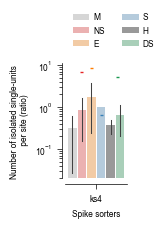

In [26]:
%%time 

# plot
fig, ax = plot_source_data(df, df_theory)

# save figures
plt.savefig("figures/8_source_data/fig5b/fig5b.svg", bbox_inches="tight", **savefig_cfg)

### Create source dataset

* Execution time: 13 ms

In [30]:
%%time

# save source datasets
df.to_excel("figures/8_source_data/fig5b/fig5b.xlsx", index=False)
df_theory.to_excel("figures/8_source_data/fig5b/fig5b_theory.xlsx", index=False)

# report
display(df)
display(df_theory)

,layer,n_sites,yield per site,experiments,sorters,depth
0,L2/3,42,0.023810,M,ks4,M
1,L4,34,0.029412,M,ks4,M
2,L5,42,0.476190,M,ks4,M
3,L6,98,0.755102,M,ks4,M
0,L1,16,0.062500,NS,ks4,NS
1,L2/3,47,0.042553,NS,ks4,NS
2,L4,19,1.368421,NS,ks4,NS
3,L5,52,2.230769,NS,ks4,NS
4,L6,68,0.573529,NS,ks4,NS
0,L1,16,0.000000,E,ks4,E


,experiments,yield per site (theory)
0,NS,6.882353
1,E,8.442308
2,S,0.651042
3,DS,5.272727


CPU times: user 10.6 ms, sys: 1.01 ms, total: 11.6 ms
Wall time: 13 ms


### Load

* Execution time 9 ms

In [32]:
%%time

df = pd.read_excel("figures/8_source_data/fig5b/fig5b.xlsx")
df_theory = pd.read_excel("figures/8_source_data/fig5b/fig5b_theory.xlsx")

CPU times: user 7.66 ms, sys: 994 µs, total: 8.66 ms
Wall time: 8.39 ms


### Re-plot

* Execution time: 55 ms

CPU times: user 56.3 ms, sys: 1.01 ms, total: 57.3 ms
Wall time: 55.3 ms


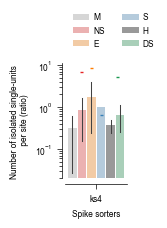

In [33]:
%%time

# plot
fig, ax = plot_source_data(df, df_theory)